(0.0, 264.4139184119238)

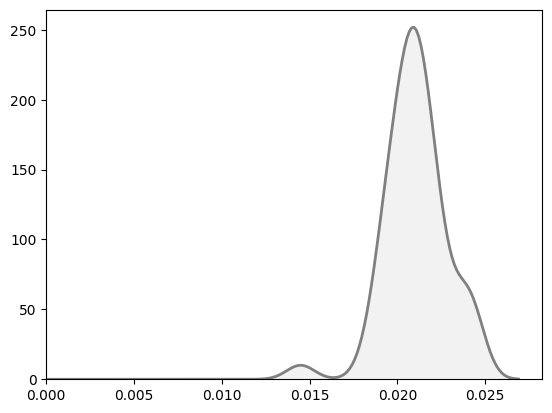

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------- Parameters -------------------
L = 40                 # system size
p = 0.4                 # control probability
num_circuits = 50       # circuit realizations
num_shots   = 1000      # shots per circuit
t_max = L**2 // 2       # 5000 time steps

# ------------------- Generate one circuit -------------------
def generate_circuit():
    """Return list of (op, i0, T) where i0 = 0‑based position, T=4x4 transition matrix for 'B'."""
    circuit = []
    pos = 1  # 1‑based current position
    for _ in range(t_max):
        # Boundary conditions
        if pos == 1:
            op = 'B'
            next_pos = 2
        elif pos == L:
            op = 'C'
            next_pos = L - 1
        else:
            if np.random.rand() < p:
                op = 'C'
                next_pos = pos - 1
            else:
                op = 'B'
                next_pos = pos + 1

        if op == 'B':
            # Columns of Haar‑induced transition matrix are Dirichlet(1,1,1,1)
            T = np.random.dirichlet([1,1,1,1], size=4).T  # each column sums to 1
            circuit.append(('B', pos-1, T))               # 0‑based index for qubit i
        else:
            circuit.append(('C', pos-1, None))
        pos = next_pos
    return circuit

# ------------------- Run all shots for one circuit (vectorized) -------------------
def simulate_circuit(circuit):
    bits = np.zeros((num_shots, L), dtype=np.int8)  # all start at |000...0>
    for op, i, T in circuit:
        if op == 'C':
            bits[:, i] = 0
        else:  # 'B' scrambler
            # Encode two‑bit state: qubit i is MSB, qubit i+1 is LSB
            s = 2 * bits[:, i] + bits[:, i+1]   # values 0,1,2,3
            for s_val in range(4):
                mask = (s == s_val)
                n = mask.sum()
                if n == 0: continue
                probs = T[:, s_val]              # distribution for this s
                s_new = np.random.choice(4, size=n, p=probs)
                bits[mask, i]   = s_new // 2     # MSB
                bits[mask, i+1] = s_new % 2      # LSB

    # Magnetisation density Mz = (1/L) Σ (1 - 2*b) = 1 - 2*(mean bit)
    Mz = 1 - 2 * bits.mean(axis=1)               # shape (num_shots,)
    return np.var(Mz, ddof=1)                    # variance over shots

# ------------------- Main simulation -------------------
variances = []
for c in range(num_circuits):
    print(f"Simulating circuit {c+1}/{num_circuits}", end='\r')
    circ = generate_circuit()
    var = simulate_circuit(circ)
    variances.append(var)

variances = np.array(variances)

# ------------------- Plot histogram (to match the "bar‑graph" look) -------------------
from scipy.stats import gaussian_kde
kde = gaussian_kde(variances)
x = np.linspace(0, variances.max()*1.1, 200)
plt.plot(x, kde(x), color='grey', lw=2)
plt.fill_between(x, kde(x), alpha=0.1, color='grey')
plt.xlim(left=0)
plt.ylim(bottom=0)

Running simulation...
L=12, p=0.00: O=0.0777 +/- 0.0062
L=12, p=0.03: O=0.0775 +/- 0.0063
L=12, p=0.06: O=0.0767 +/- 0.0063
L=12, p=0.09: O=0.0845 +/- 0.0064
L=12, p=0.12: O=0.0757 +/- 0.0062
L=12, p=0.15: O=0.1008 +/- 0.0060
L=12, p=0.18: O=0.0921 +/- 0.0061
L=12, p=0.21: O=0.1015 +/- 0.0062
L=12, p=0.24: O=0.1013 +/- 0.0063
L=12, p=0.27: O=0.1077 +/- 0.0064
L=12, p=0.30: O=0.1173 +/- 0.0065
L=12, p=0.33: O=0.1383 +/- 0.0066
L=12, p=0.36: O=0.1488 +/- 0.0066
L=12, p=0.39: O=0.1983 +/- 0.0067
L=12, p=0.42: O=0.2296 +/- 0.0072
L=12, p=0.45: O=0.3110 +/- 0.0077
L=12, p=0.48: O=0.3944 +/- 0.0077
L=12, p=0.51: O=0.4774 +/- 0.0077
L=12, p=0.54: O=0.5816 +/- 0.0070
L=12, p=0.57: O=0.6606 +/- 0.0063
L=12, p=0.60: O=0.7288 +/- 0.0052
L=16, p=0.00: O=0.0601 +/- 0.0054
L=16, p=0.03: O=0.0597 +/- 0.0053
L=16, p=0.06: O=0.0718 +/- 0.0056
L=16, p=0.09: O=0.0623 +/- 0.0055
L=16, p=0.12: O=0.0609 +/- 0.0055
L=16, p=0.15: O=0.0645 +/- 0.0055
L=16, p=0.18: O=0.0541 +/- 0.0054
L=16, p=0.21: O=0.0734 +/-

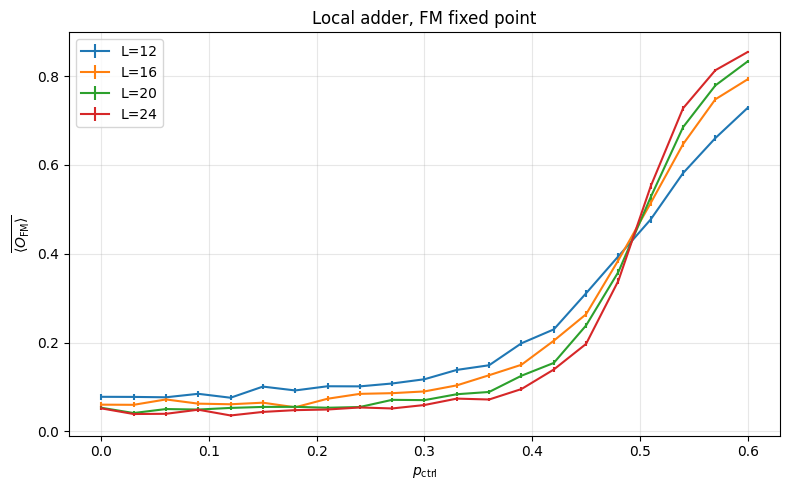

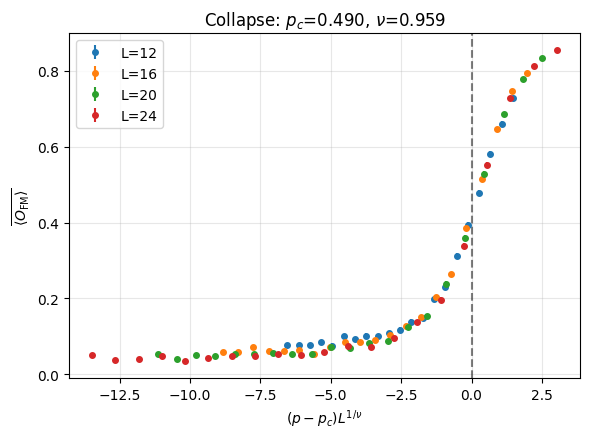

In [4]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# --------------------------
# 1. Markov chain simulation
# --------------------------
def trajectory(L, p_ctrl, t_max):
    bits = np.zeros(L, dtype=np.int8)   # all zeros initially
    i = 1                               # 1‑based index
    for _ in range(t_max):
        # boundaries
        if i == 1:
            op, next_i = 'B', 2
        elif i == L:
            op, next_i = 'C', L-1
        else:
            if np.random.rand() < p_ctrl:
                op, next_i = 'C', i-1
            else:
                op, next_i = 'B', i+1

        if op == 'C':
            bits[i-1] = 0
        else:  # scrambler
            bits[i-1] = np.random.randint(0, 2)
            bits[i] = np.random.randint(0, 2)

        i = next_i

    # Magnetisation density (FM order parameter)
    return np.mean(1 - 2*bits)   # 1 if all zeros, -1 if all ones, but bits only 0→1

# -------------------------------
# 2. Average over many trajectories
# -------------------------------
def average_O(L, p_ctrl, t_max, n_traj=2000):
    obs = [trajectory(L, p_ctrl, t_max) for _ in range(n_traj)]
    return np.mean(obs), np.std(obs) / np.sqrt(n_traj)  # mean, std error

# ---------------------------------------------
# 3. Data collapse & critical exponent fitting
# ---------------------------------------------
def scaling_loss(params, L_vals, p_vals, means, stderrs):
    pc, nu = params
    # Create scaled x = (p - pc) * L**(1/nu)
    x_scaled = []
    y_scaled = []
    w_scaled = []
    for L, p_arr, m_arr, e_arr in zip(L_vals, p_vals, means, stderrs):
        x_scaled.append((p_arr - pc) * L**(1/nu))
        y_scaled.append(m_arr)
        w_scaled.append(1.0 / e_arr)   # weight by inverse error
    # Flatten
    x_all = np.concatenate(x_scaled)
    y_all = np.concatenate(y_scaled)
    w_all = np.concatenate(w_scaled)
    # Sort by x
    idx = np.argsort(x_all)
    x_sorted = x_all[idx]
    y_sorted = y_all[idx]
    w_sorted = w_all[idx]

    # Compute chi^2 using nearest-neighbour interpolation (Eq. A1-A3)
    N = len(x_sorted)
    chi2 = 0.0
    for i in range(1, N-1):
        # linear interpolation between i-1 and i+1
        x_left, y_left = x_sorted[i-1], y_sorted[i-1]
        x_right, y_right = x_sorted[i+1], y_sorted[i+1]
        if x_right == x_left:
            continue
        y_interp = y_left + (y_right - y_left) * (x_sorted[i] - x_left) / (x_right - x_left)
        # combined error: sigma_i^2 = sigma_yi^2 + propagated interpolation errors
        sigma2 = (1.0/w_sorted[i])**2  # variance
        # simple approximation: ignore interpolation error for quick collapse
        chi2 += (y_sorted[i] - y_interp)**2 / sigma2
    return chi2 / (N - 2)   # reduced chi^2

def fit_critical(p_vals, L_vals, means, stderrs):
    # Initial guess
    res = minimize(
        lambda par: scaling_loss(par, L_vals, p_vals, means, stderrs),
        x0=[0.5, 1.0],
        method='Nelder-Mead',
        options={'maxiter':10000, 'xatol':1e-8, 'fatol':1e-8}
    )
    return res.x   # [pc, nu]

# Bootstrapping for error bars
def bootstrap_fit(p_all, L_all, means_all, errs_all, n_boot=100):
    pc_arr = []
    nu_arr = []
    # resample trajectories: we need original trajectories, but here we simulate
    # For simplicity, we'll re-simulate a few times? Not feasible for many boots.
    # Instead, we assume we have pre‑computed means and errors, and we resample
    # using a normal approximation. This is reasonable for the classical model.
    for _ in range(n_boot):
        # resample means with normal noise
        boot_means = [m + np.random.normal(0, e) for m, e in zip(means_all, errs_all)]
        pc, nu = fit_critical(p_all, L_all, boot_means, errs_all)
        pc_arr.append(pc)
        nu_arr.append(nu)
    return np.std(pc_arr), np.std(nu_arr)

# --------------------------
# 4. Run simulation and plot
# --------------------------
if __name__ == "__main__":
    L_list = [12, 16, 20, 24]
    p_ctrl_list = np.linspace(0, 0.6, 21)   # around the critical point
    n_traj = 2000
    t_max_factor = 2   # t_max = 2*L^2

    # Store data
    all_means = []
    all_stderrs = []
    p_vals = []
    L_vals = []

    print("Running simulation...")
    for L in L_list:
        t_max = t_max_factor * L**2
        means = []
        stderrs = []
        for p in p_ctrl_list:
            m, e = average_O(L, p, t_max, n_traj)
            means.append(m)
            stderrs.append(e)
            print(f"L={L:2d}, p={p:.2f}: O={m:.4f} +/- {e:.4f}")
        all_means.append(np.array(means))
        all_stderrs.append(np.array(stderrs))
        p_vals.append(p_ctrl_list)
        L_vals.append(L)

    # Fit critical point
    pc, nu = fit_critical(p_vals, L_vals, all_means, all_stderrs)
    print(f"\nFitted pc = {pc:.4f}, nu = {nu:.4f}")

    # Plot raw data (Fig. 2b top panel style)
    plt.figure(figsize=(8,5))
    for L, m, e in zip(L_list, all_means, all_stderrs):
        plt.errorbar(p_ctrl_list, m, yerr=e, label=f'L={L}')
    plt.xlabel(r'$p_{\mathrm{ctrl}}$')
    plt.ylabel(r'$\overline{\langle O_{\mathrm{FM}}\rangle}$')
    plt.legend()
    plt.title('Local adder, FM fixed point')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('fig2b_raw.png', dpi=150)
    plt.show()

    # Data collapse (inset of Fig. 2b)
    plt.figure(figsize=(6,4.5))
    for L, m, e in zip(L_list, all_means, all_stderrs):
        x = (p_ctrl_list - pc) * L**(1/nu)
        plt.errorbar(x, m, yerr=e, fmt='o', ms=4, label=f'L={L}')
    plt.xlabel(r'$(p - p_c) L^{1/\nu}$')
    plt.ylabel(r'$\overline{\langle O_{\mathrm{FM}}\rangle}$')
    plt.axvline(0, color='k', linestyle='--', alpha=0.5)
    plt.legend()
    plt.title(f'Collapse: $p_c$={pc:.3f}, $\\nu$={nu:.3f}')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('fig2b_collapse.png', dpi=150)
    plt.show()